In [37]:
import nds_toolbox
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os

In [38]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9

plt.rcParams.update({

    # --- Fonts ---
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,

    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


In [157]:
from nds_toolbox.sim.bursts.simulator import simulate_bursty_signal
from nds_toolbox.preprocessing.features import (compute_tde,trim_data)
from nds_toolbox.preprocessing.features import choose_embedding_dim
from nds_toolbox.utils.helper import compare_decoding_performance

In [173]:
sim_cond = "2states_multi"
signal_dir = "../data/simulations"
performance_dir = "../data/performance"

sim_data = np.load(f'{signal_dir}/{sim_cond}_data.npz', allow_pickle=True)
signal_sample = sim_data['signal_samples']
states_sample = sim_data['states_samples']
bursts_sample = sim_data['bursts_samples']
print("shape of signal_sample", signal_sample.shape)


######## SHOW CODE

signal = signal_sample[0,0,0,0]
states = states_sample[0,0,0,0]
bursts = bursts_sample[0,0,0,0]

signal2 = signal_sample[0,0,0,5]
states2 = states_sample[0,0,0,5]
bursts2 = bursts_sample[0,0,0,5]


##### generate ground truth

combined_states = np.empty_like(states)
    
state_dict = {'00': 0}
state_num = 1
for i, (s1, s2) in enumerate(zip(states, states2)):
    s =  str(s1) + str(s2)
    if s not in state_dict:
        state_dict[s] = state_num
        state_num += 1
    combined_states[i] = state_dict[s]

print(state_dict.keys())

        

print(combined_states)  




freq = np.array([10])
freq2 = np.array([10])
true_num_states = state_num
seed = 2025
fs = 200
time_vec = np.linspace(0, 60, int(fs * 60))
snr_db = 2
state_transition = 'return_to_baseline'

true_states_onehot = np.eye(true_num_states)[combined_states]

print(true_num_states)


shape of signal_sample (10, 2, 2, 6)
dict_keys(['00', '11', '01', '10'])
[1 1 1 ... 1 1 1]
4


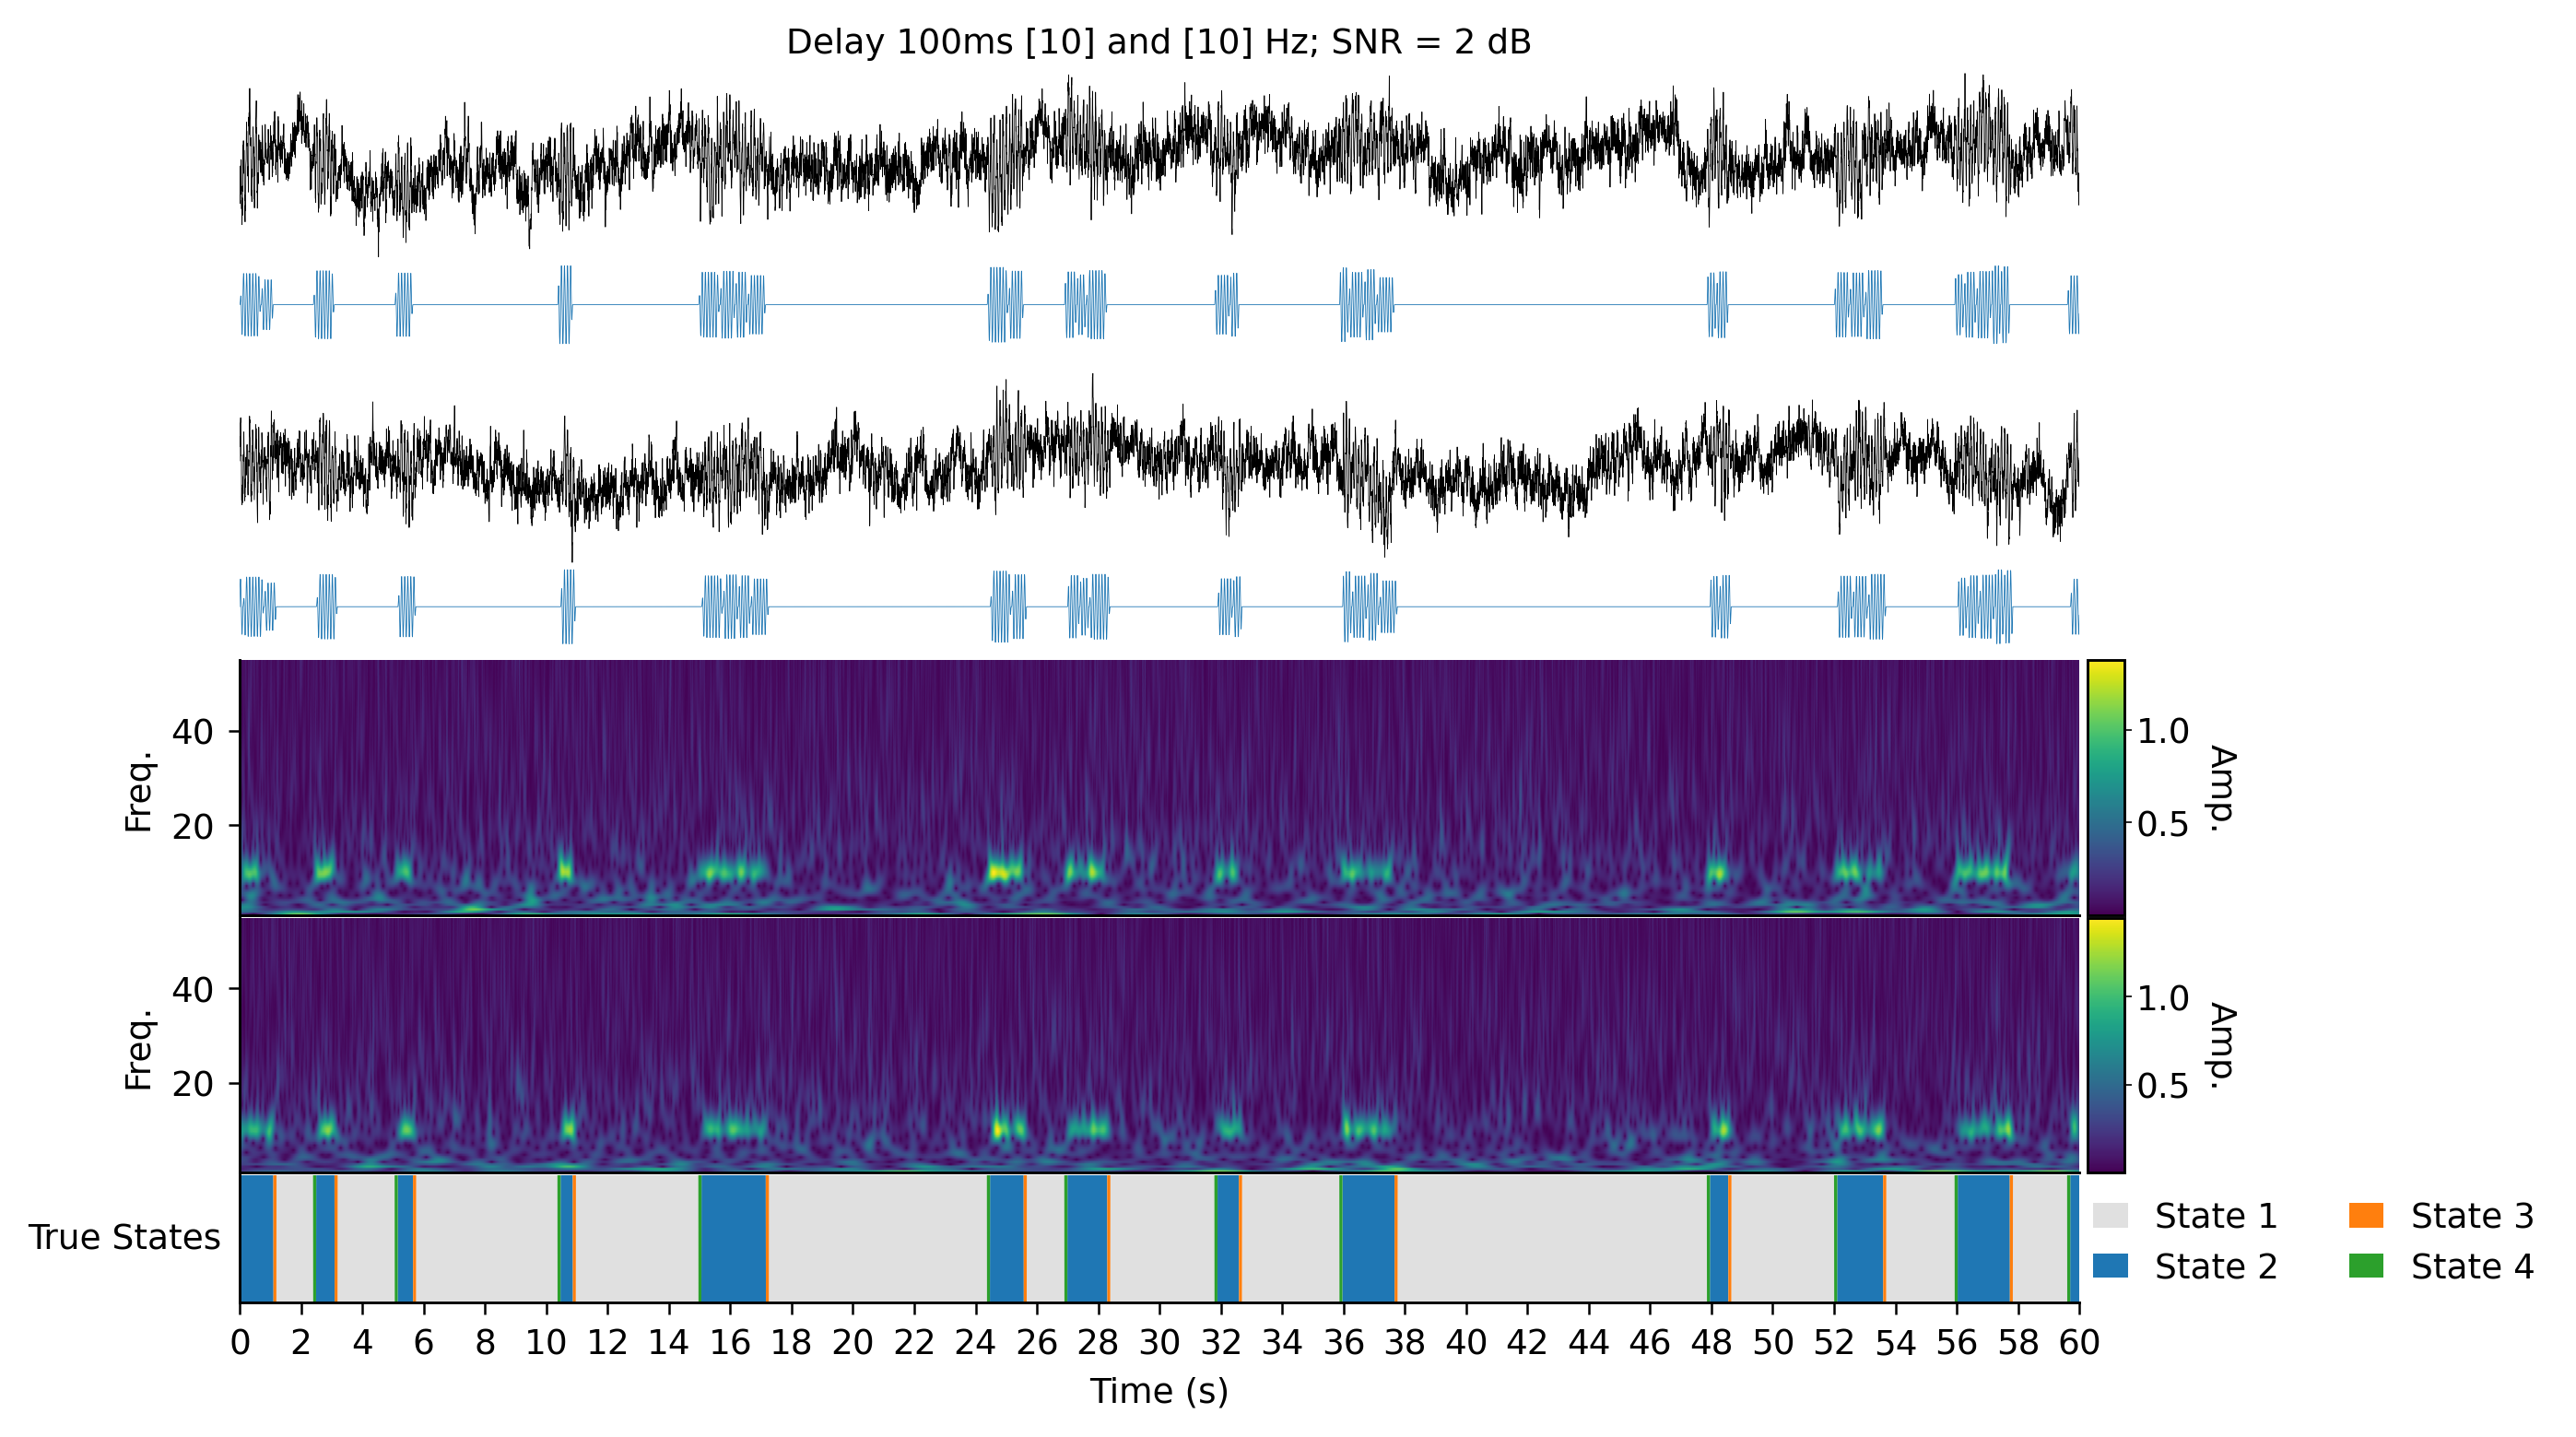

In [175]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from nds_toolbox.preprocessing.features import compute_wavelet


heading = f"Delay 100ms {freq} and {freq2} Hz; SNR = {snr_db} dB"
plot_t = 60


#compute wavelets
t1, f1, amp1 = compute_wavelet(signal[:plot_t * fs], fs, f_min=1, f_max=80, df=0.5, wavelet="cmor1.5-1.0")
t2, f2, amp2 = compute_wavelet(signal2[:plot_t * fs], fs, f_min=1, f_max=80, df=0.5, wavelet="cmor1.5-1.0")

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(true_num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i + 1}" for i in range(true_num_states)]

mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 5),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios": [0.7,0.7,0.6, 0.6, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)

axes["b1"].plot(time_vec[:plot_t * fs], 0.3 * (signal[:plot_t * fs]), lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)

axes["b1"].set_title(heading, pad=0.3)

axes["b1"].plot(time_vec[:plot_t * fs], 0.3 * (-2 + bursts[:plot_t * fs] * (states[:plot_t * fs] == 1)), lw=0.2,
                color=colors[1])


axes["b1"].set_yticks([])
axes["b1"].set_xticks([])

for s in ("top", "right", "bottom", "left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)



axes["b2"].plot(time_vec[:plot_t * fs], 0.3 * (signal2[:plot_t * fs]), lw=0.2, color="k")
axes["b2"].grid(False)
axes["b2"].set_frame_on(False)


axes["b2"].plot(time_vec[:plot_t * fs], 0.3 * (-2 + bursts2[:plot_t * fs] * (states2[:plot_t * fs] == 1)), lw=0.2,
                color=colors[1])

axes["b2"].set_yticks([])
axes["b2"].set_xticks([])

for s in ("top", "right", "bottom", "left"):
    axes["b2"].spines[s].set_visible(False)
axes["b2"].set_frame_on(False)
axes["b2"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)






im = axes["b3"].imshow(
    amp1, extent=[t1[0], t1[-1], f1[0], f1[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp1.min(), vmax=amp1.max()
)
axes["b3"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)


#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b3"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b3"].yaxis.set_major_locator(MultipleLocator(20))

axes["b3"].set_ylim(1, 55)

cax = inset_axes(
    axes["b3"],  # parent axis
    width="2%",  # width as percentage of a2
    height="100%",  # match the height
    loc="center right",  # position inside a2
    borderpad=-1.3  # negative value moves it outside slightly
)


# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)




im = axes["b4"].imshow(
    amp2, extent=[t2[0], t2[-1], f2[0], f2[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp2.min(), vmax=amp2.max()
)
axes["b4"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)


#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b4"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b4"].yaxis.set_major_locator(MultipleLocator(20))

axes["b4"].set_ylim(1, 55)

cax = inset_axes(
    axes["b4"],  # parent axis
    width="2%",  # width as percentage of a2
    height="100%",  # match the height
    loc="center right",  # position inside a2
    borderpad=-1.3  # negative value moves it outside slightly
)


# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)





axes["b5"].stackplot(time_vec[:plot_t * fs], true_states_onehot[:plot_t * fs].T, linewidth=0, colors=colors,
                     labels=state_labels)
axes["b5"].set_ylabel(f"True States", rotation=0, labelpad=30, va="center")
axes["b5"].tick_params(axis='y', which='both', left=False, labelleft=False)

for key in ["b1", "b2", "b3", "b4","b5"]:
    axes[key].sharex(axes["b1"])

axes["b5"].set_xlabel("Time (s)")
axes["b5"].xaxis.set_major_locator(MultipleLocator(2.0))
axes["b5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b5"].set_ylim(0, 1)
axes["b5"].set_xlim(0, plot_t)

axes["b5"].spines["bottom"].set_visible(True)  # keep x-axis frame

handles, labels = axes["b5"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",  # anchor to left of the bbox
           ncol=2,
           bbox_to_anchor=(0.981, 0.12),  # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)

plt.show()




# Time delay embedding (TDE)

In [ ]:
#step1: standarize the signal before TDE
signal = (signal - np.mean(signal))/ np.std(signal)
signal2 = (signal2 - np.mean(signal2))/ np.std(signal2)

#step2: TDE
#number of embeddings is chosen based on 2.5 cycles of the target frequency
#Here we have multiple candidate frequencies, so we use mean frequency as our target

num_emb = choose_embedding_dim(np.mean(freq2), fs, min_cycles = 2.5, ensure_odd = True, verbose=True)
#you can also set it to some reasonable embeddings, say num_emb = 15
num_emb = 25

tde_signal = compute_tde(signal, num_emb)
tde_signal2 = compute_tde(signal2, num_emb)

#after TDE, num_emb//2 data points are lost from both ends of the signal
#so here we trim our signal and true state for later
trimmed_signal = trim_data(signal, num_emb, verbose = False)
trimmed_signal2 = trim_data(signal2, num_emb, verbose= False)
trimmed_states = trim_data(combined_states, num_emb, verbose = False)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))




#roughly speaking, the expected number of states is "ln n"
num_states = int(np.ceil(np.log(len(trimmed_signal)))) # E[K] = alpha ln n
print(num_states)
# this sets K above the expected occupied clusters

#num_states = 3 #(if you wanna test with the ground truth)

num_models = 1 #default: 10
num_epochs = 3000#default: 3000
n_jobs = 1 #increase the number of jobs when you want to multi process the inference
lr = 1e-2

###### FIT DP-GMM ##########

empty_tde = np.empty_like(tde_signal)

#tde_signal = np.concatenate([tde_signal, empty_tde], axis=1)
#tde_signal2 = np.concatenate([tde_signal2, empty_tde], axis=1)


tde_signal = np.concatenate([tde_signal, tde_signal2], axis=1)




print(f"TDE_SHAPE:  {tde_signal.shape}")

from nds_toolbox.models.dpgmm_numpyro import fit_DPGMM, truncate, get_states

lrs = [0.01]
results = []

for i in lrs:
    dpgmm_result = fit_DPGMM(data=tde_signal,
                             num_states=num_states,
                             use_epoch_tqdm=True,
                             n_jobs=n_jobs,
                             use_model_tqdm=True,
                             num_models=num_models,
                             main_seed=seed,
                             num_epochs = num_epochs,
                             learning_rate=i,
                             verbose=True)
    results.append(dict(dpgmm_result))

                            


Chosen window size = 0.25 (sec): minimum cycles of 2.5 at 10.0 Hz
Chosen embedding dimension = 51: sampling rate = 200 Hz
25 data points were lost from both ends.
data shape: (11950, 51)
25 data points were lost from both ends.
data shape: (11950, 51)
10
TDE_SHAPE:  (11950, 102)


Fitting 1 DPGMM models:   0%|          | 0/1 [00:00<?, ?model/s]

(11950, 102)
STACKED DIMS!
102
(11950, 102)
STACKED DIMS!
102
(11950, 102)
STACKED DIMS!
102
(11950, 102)


STACKED DIMS!
102
(11950, 102)


100%|██████████| 3000/3000 [04:54<00:00, 10.19it/s, init loss: 1.9366, avg. loss [2851-3000]: 0.7746]


STACKED DIMS!
102
(11950, 102)
STACKED DIMS!
102
(11950, 102)


Best ELBO: 0.774495
Best model ID: 0


In [166]:
dpgmm_result.keys()


dict_keys(['est_params', 'loss_best', 'model_id_best', 'seed_best', 'loss_all'])

In [177]:
est_params = dpgmm_result["est_params"]
loss_best = dpgmm_result["loss_best"]
loss_all = dpgmm_result["loss_all"]


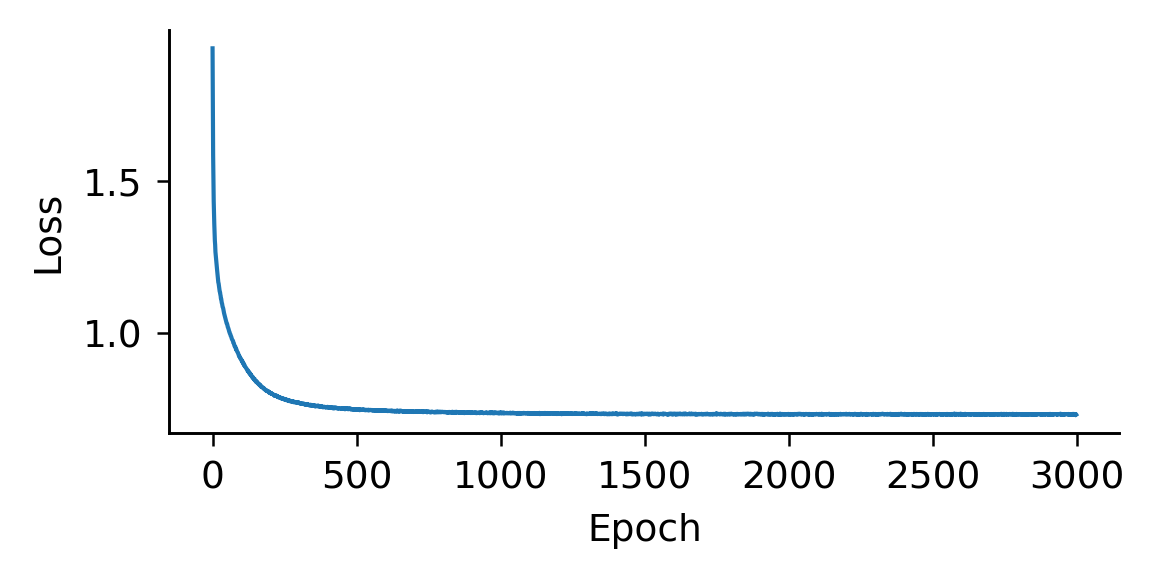

In [95]:
fig, ax = plt.subplots(figsize=(4, 2))
ax.plot(np.array(loss_all).T)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

In [178]:
from nds_toolbox.utils.helper import match_states
from sklearn.metrics import matthews_corrcoef
import jax.numpy as jnp

r = results[0]

est_params = r["est_params"]
alpha = est_params["alpha"]
weights = est_params["weights"]
means = est_params["means"]
covs = est_params["covs"]

#truncate tiny mixture weights and renormalize the weights
trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info=True)
print("MEANS")
print(means.shape)

#effeci
num_effective_states = len(trunc_weights)



# example input format: signals = [sig1, sig2]
# where sig1, sig2 are sequences of shape (T, F1) and (T, F2)
sig1 = jnp.array(tde_signal[0])   # (T, F1)
sig2 = jnp.array(tde_signal[1])   # (T, F2)

# check lengths match
assert sig1.shape[0] == sig2.shape[0], "time lengths must match"
T = sig1.shape[0]

# stack per-time features: z[t] = concat(sig1[t], sig2[t])
z = jnp.concatenate([sig1, sig2], axis=-1)   # shape (T, F1+F2)

print(trunc_means.shape)
print(trunc_covs.shape)
print(trunc_weights.shape)
print(z.shape)




#get the estimated states based on the learned parameters
est_states_dpgmm = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)

print(est_states_dpgmm.shape)


mapper = np.array([1, 0])
#est_states_dpgmm = mapper[est_states_dpgmm]

print(est_states_dpgmm)
print(trimmed_states)

#one hot vector of estimated states
est_states_dpgmm_onehot = np.eye(5)[est_states_dpgmm]






#one hot vector of true states
trimmed_states_onehot = np.eye(5)[trimmed_states]
print(est_states_dpgmm_onehot.shape)
print(trimmed_states_onehot.shape)

print(est_states_dpgmm[0])


#order the estimated states
##order, est_states_dpgmm_onehot = match_states(trimmed_states_onehot, est_states_dpgmm_onehot, verbose=False)
#onehot vector -> a signal array
#est_states_dpgmm = np.argmax(est_states_dpgmm_onehot, axis=1)




[truncate] mass_threshold=0.990 | kept 1/10 | mass kept=0.9979 | mass dropped=0.0021 | removed_edge=0 (cv>0.2)
MEANS
(10, 102)
(1, 102)
(1, 102, 102)
(1,)
(204,)
(11950,)
[0 0 0 ... 0 0 0]
[1 1 1 ... 1 1 1]
(11950, 5)
(11950, 5)
0


In [183]:

mcc_dpgmm = matthews_corrcoef(trimmed_states, est_states_dpgmm)
print()
print("mcc" ,mcc_dpgmm)



mcc 0.0


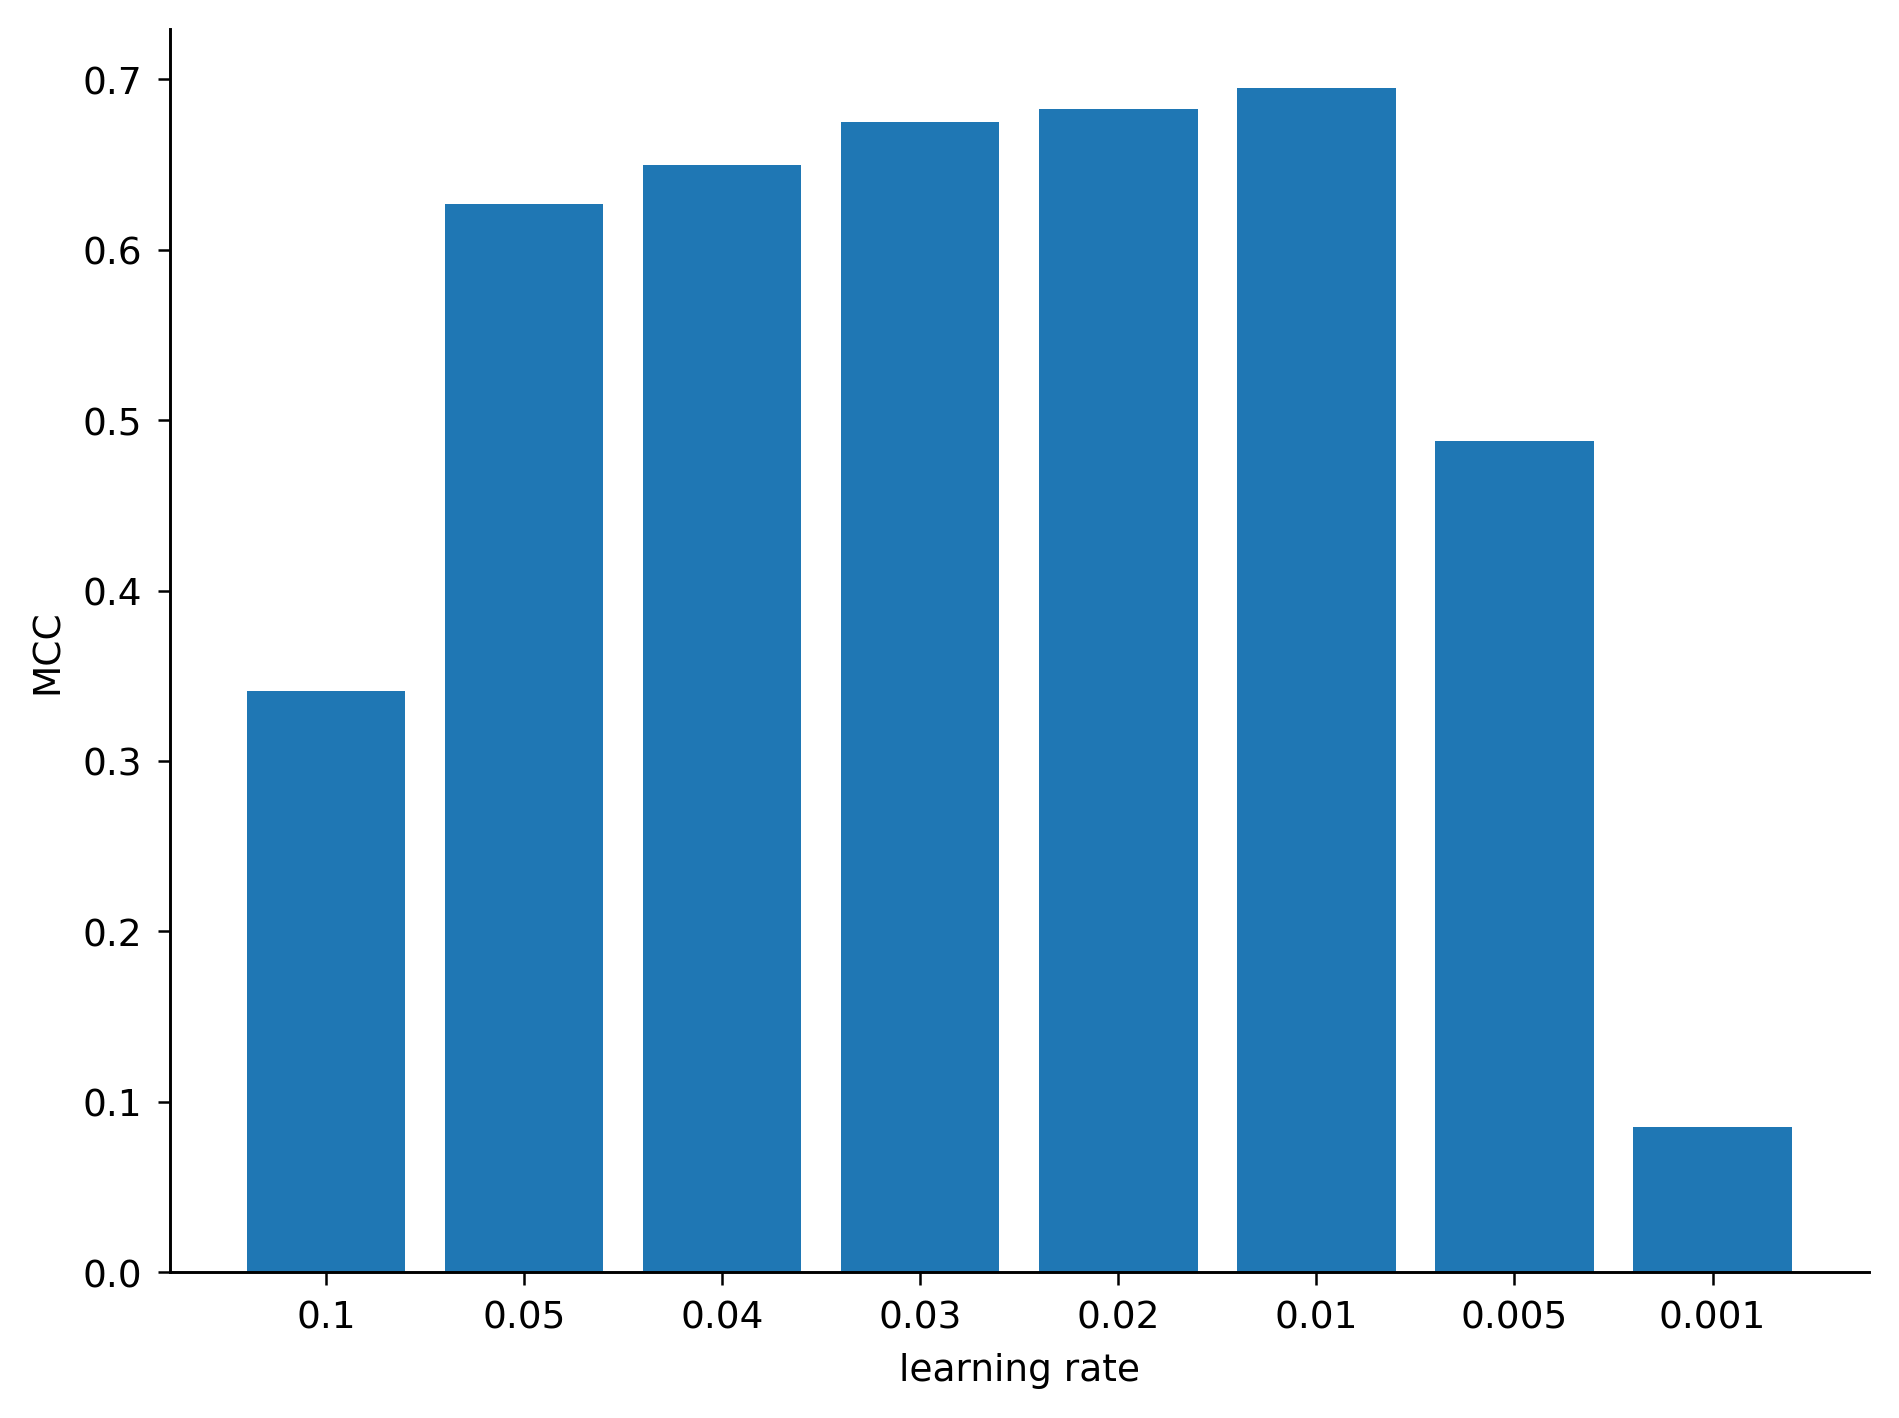

In [184]:
fig, ax = plt.subplots()
lrs = ['0.1', '0.05', '0.04', '0.03', '0.02', '0.01', '0.005', '0.001']
mccs = [0.3412436713193368, 0.6268492917080764, 0.6499866279024207, 0.6748554250715381, 0.6824025650964645, 0.6947898526469216, 0.48761848177043066, 0.08528740556856759]
ax.bar(lrs, mccs)
ax.set_ylabel('MCC')
ax.set_xlabel('learning rate')
plt.show()

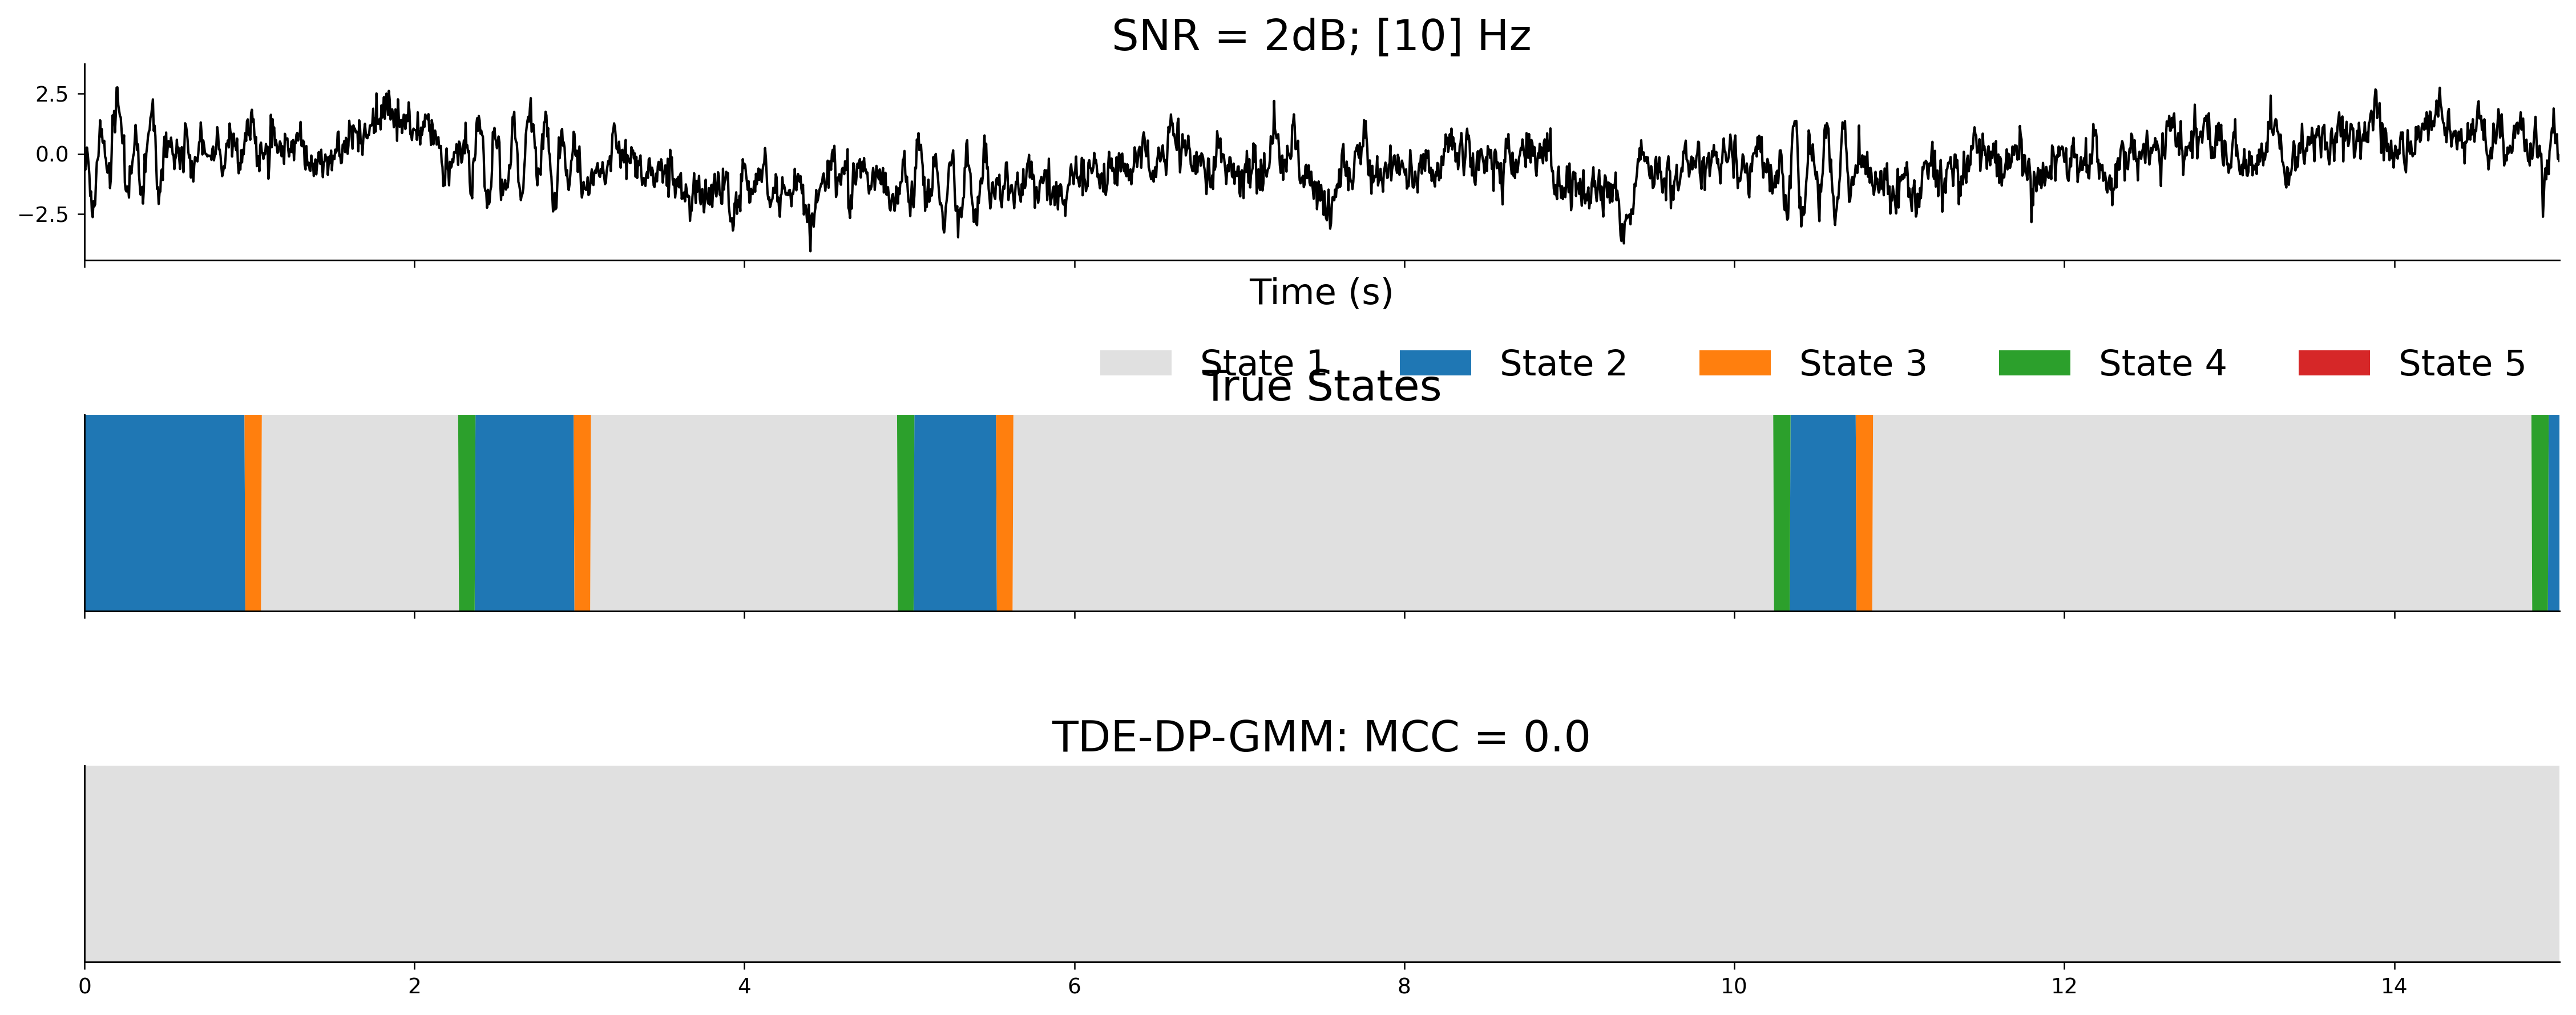

In [185]:

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]

fig, ax = plt.subplots(3, 1, figsize = (15, 6), sharex = True)

ax[0].plot(trimmed_time_vec, trimmed_signal, color = "k")
ax[0].set_xlabel("Time (s)", fontsize = 15)
ax[0].set_title(f"SNR = {snr_db}dB; {freq} Hz", fontsize = 18)
ax[0].set_xlim(0, 15)


ax[1].stackplot(trimmed_time_vec, trimmed_states_onehot.T, colors = colors, labels = state_labels, linewidth = 0)
ax[1].set_title("True States", fontsize = 18)
ax[1].set_ylim(0, 1)
ax[1].set_yticks([])



ax[2].stackplot(trimmed_time_vec, est_states_dpgmm_onehot.T, colors = colors, linewidth = 0)
ax[2].set_title(f"TDE-DP-GMM: MCC = {np.round(mcc_dpgmm, 3)}", fontsize = 18)
ax[2].set_ylim(0, 1)
ax[2].set_yticks([])


ax[1].legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=num_states,
    frameon=False,
    fontsize=15,
)



plt.tight_layout()
plt.show()



DOP
(1, 102, 102)


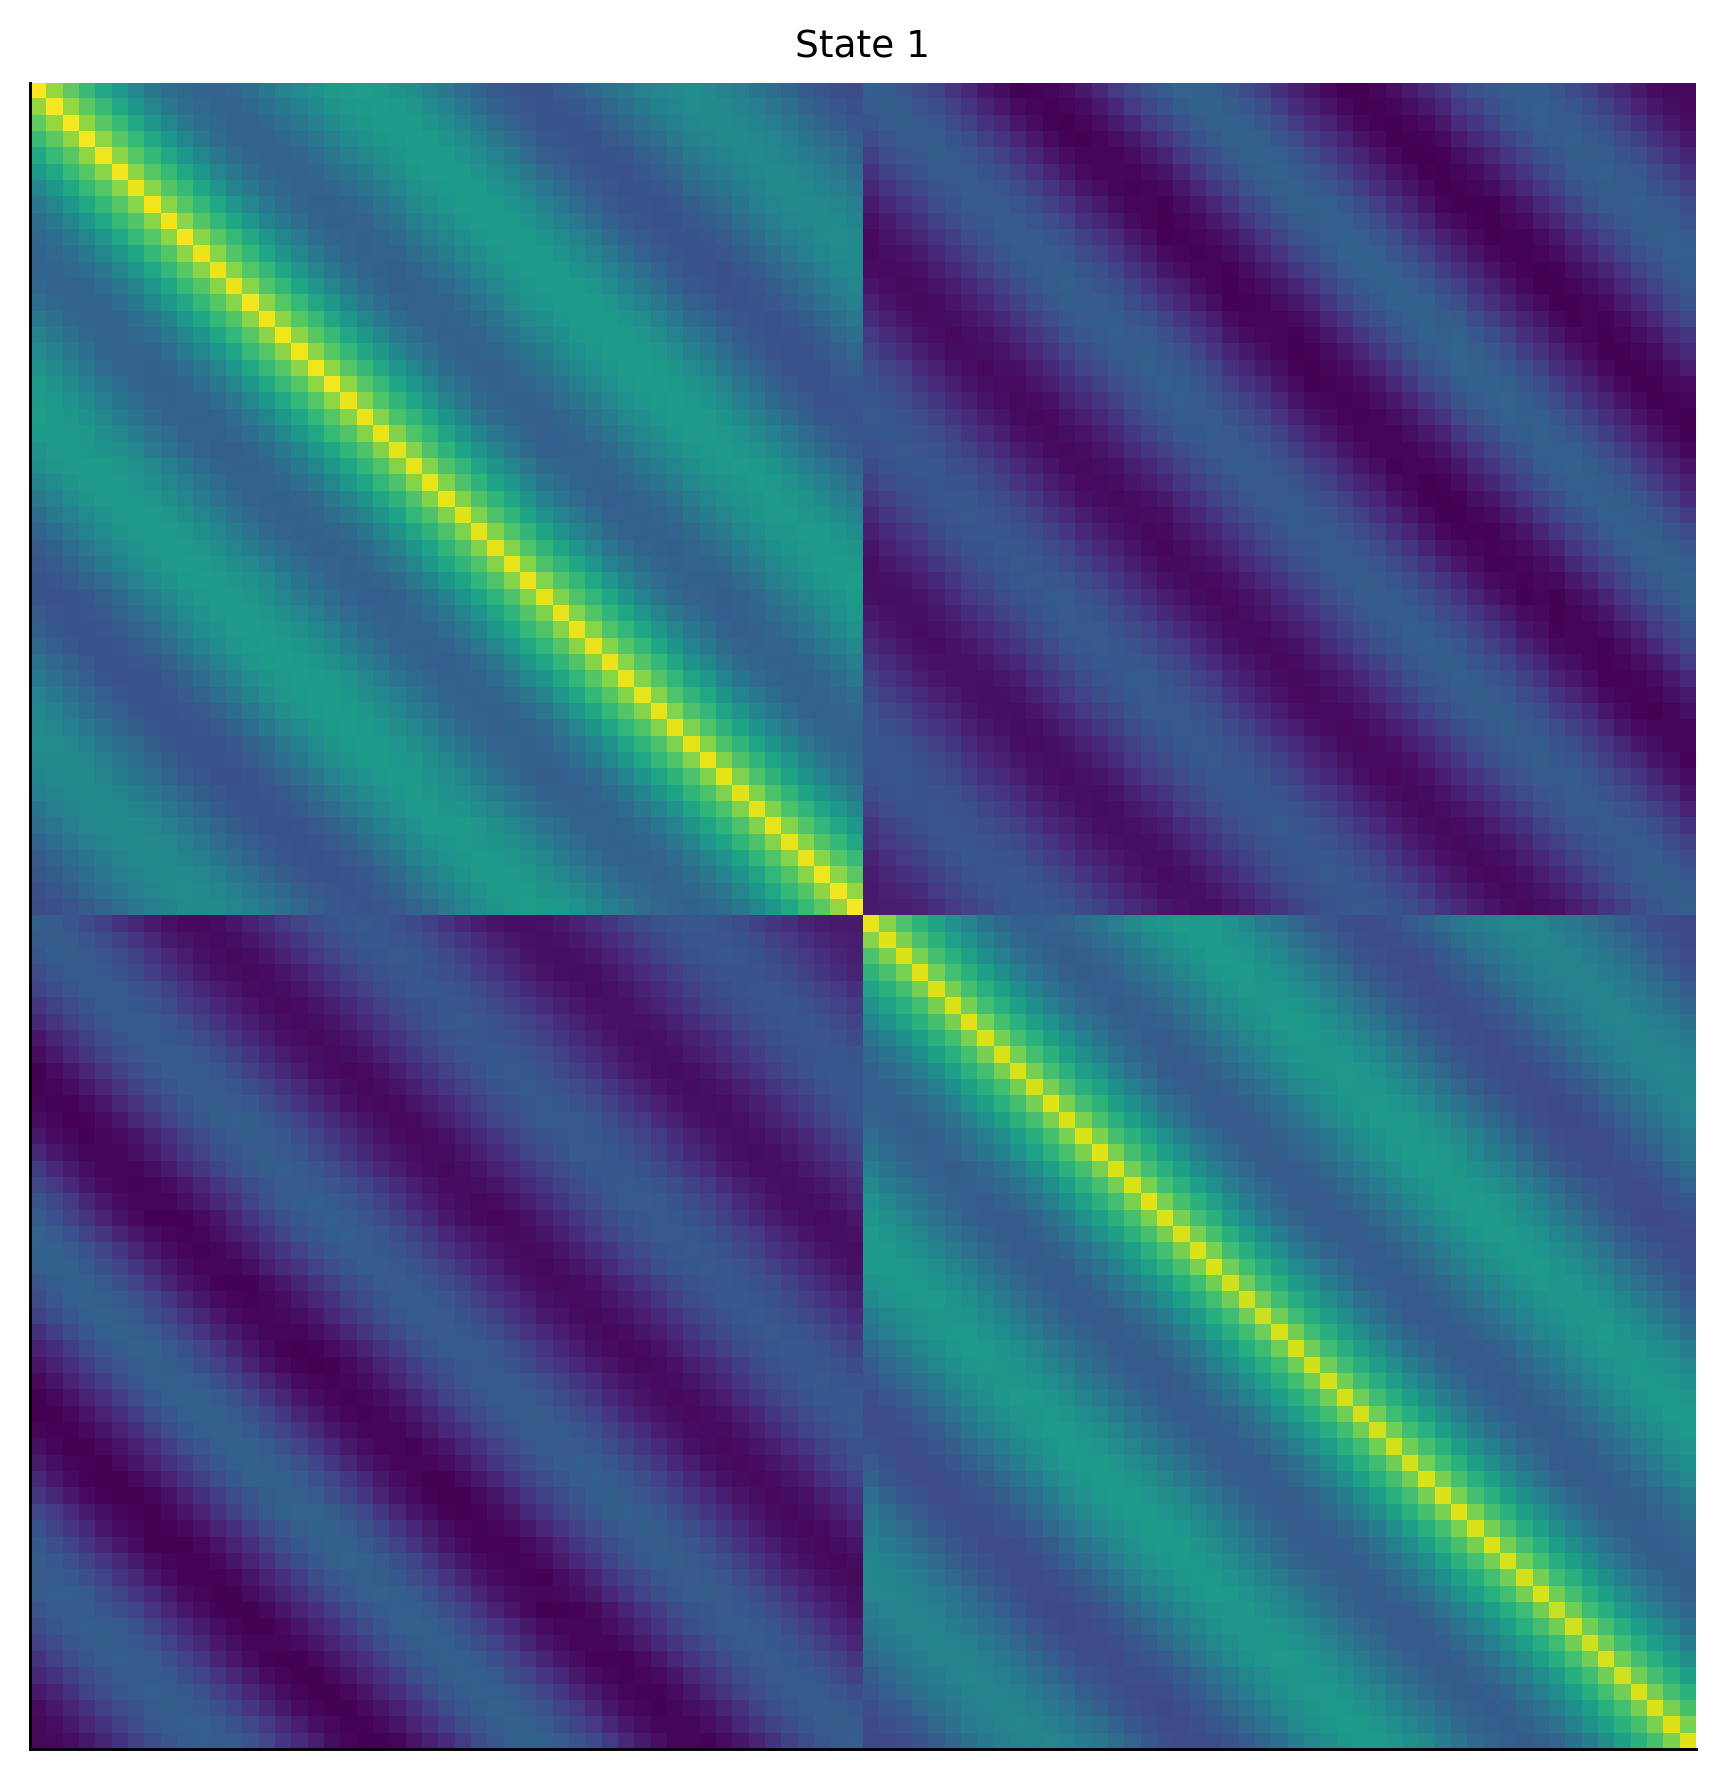

In [186]:


fig, ax = plt.subplots(1, trunc_covs.shape[0], figsize=(10, 6), sharex=True, sharey=True)
if trunc_covs.shape[0] == 1:
    ax.imshow(trunc_covs[0], cmap="viridis")
    ax.set_title(f"State {1}")
    ax.set_xticks([])
    ax.set_yticks([])
    print("DOP")
else:
    for i, cov in enumerate(trunc_covs):
        print("WOP")
        ax[i].imshow(cov, cmap="viridis")
        ax[i].set_title(f"State {i+1}")
        ax[i].set_xticks([])
        ax[i].set_yticks([])
print(trunc_covs.shape)
plt.show()


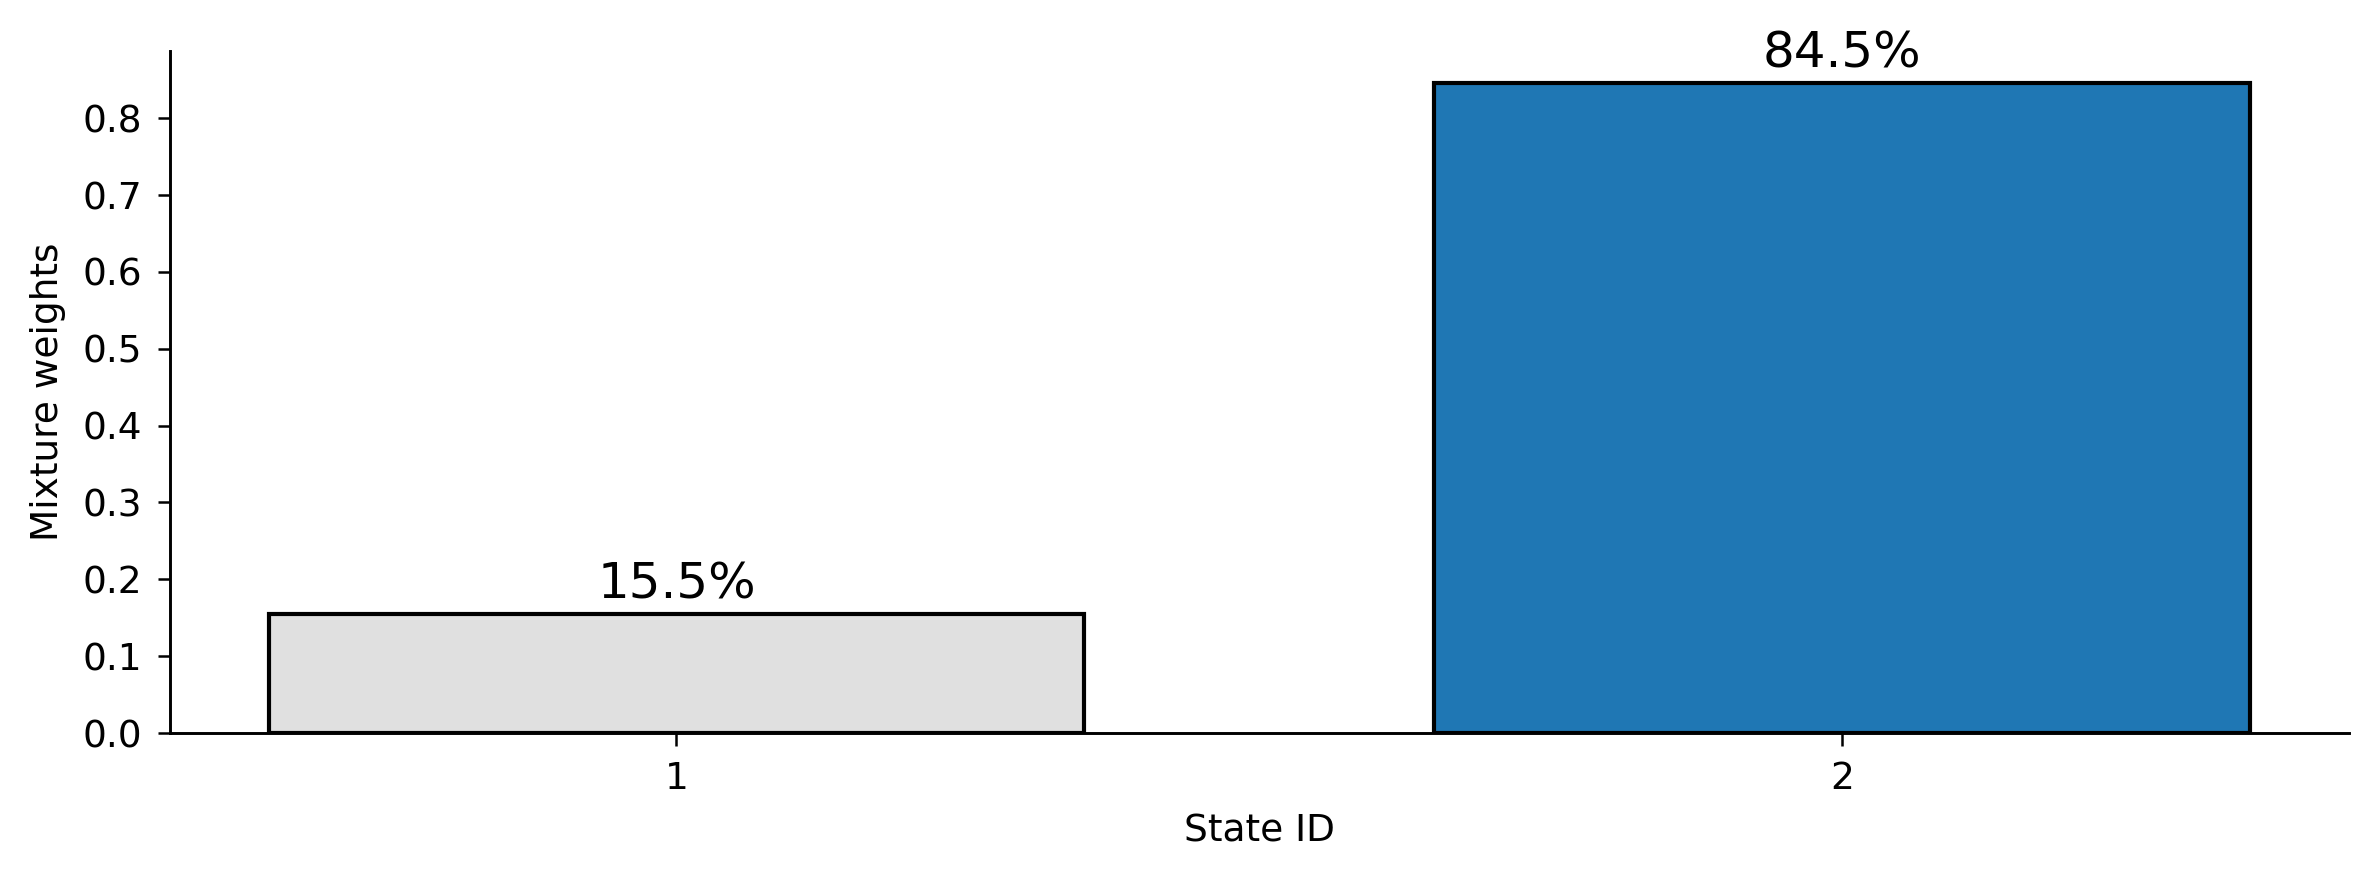

In [148]:

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

for k, w in enumerate(trunc_weights):
        ax.bar(
            k,
            w,
            width=0.7,
            color=colors[k],
            zorder=1,
            align="center",
            edgecolor="k",
        )
        ax.text(
            k,
            w + 0.02,
            f"{w * 100:.1f}%",
            ha="center",
            color="k",
            fontsize=12,
        )

ax.set_ylabel("Mixture weights")
ax.set_xlabel("State ID")
ax.set_xticks(np.arange(num_effective_states), labels=np.arange(1, num_effective_states + 1))
plt.show()

(1, 102, 102)


/home/gerrit/Bachelor/MC-TDE-DP-GMM/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


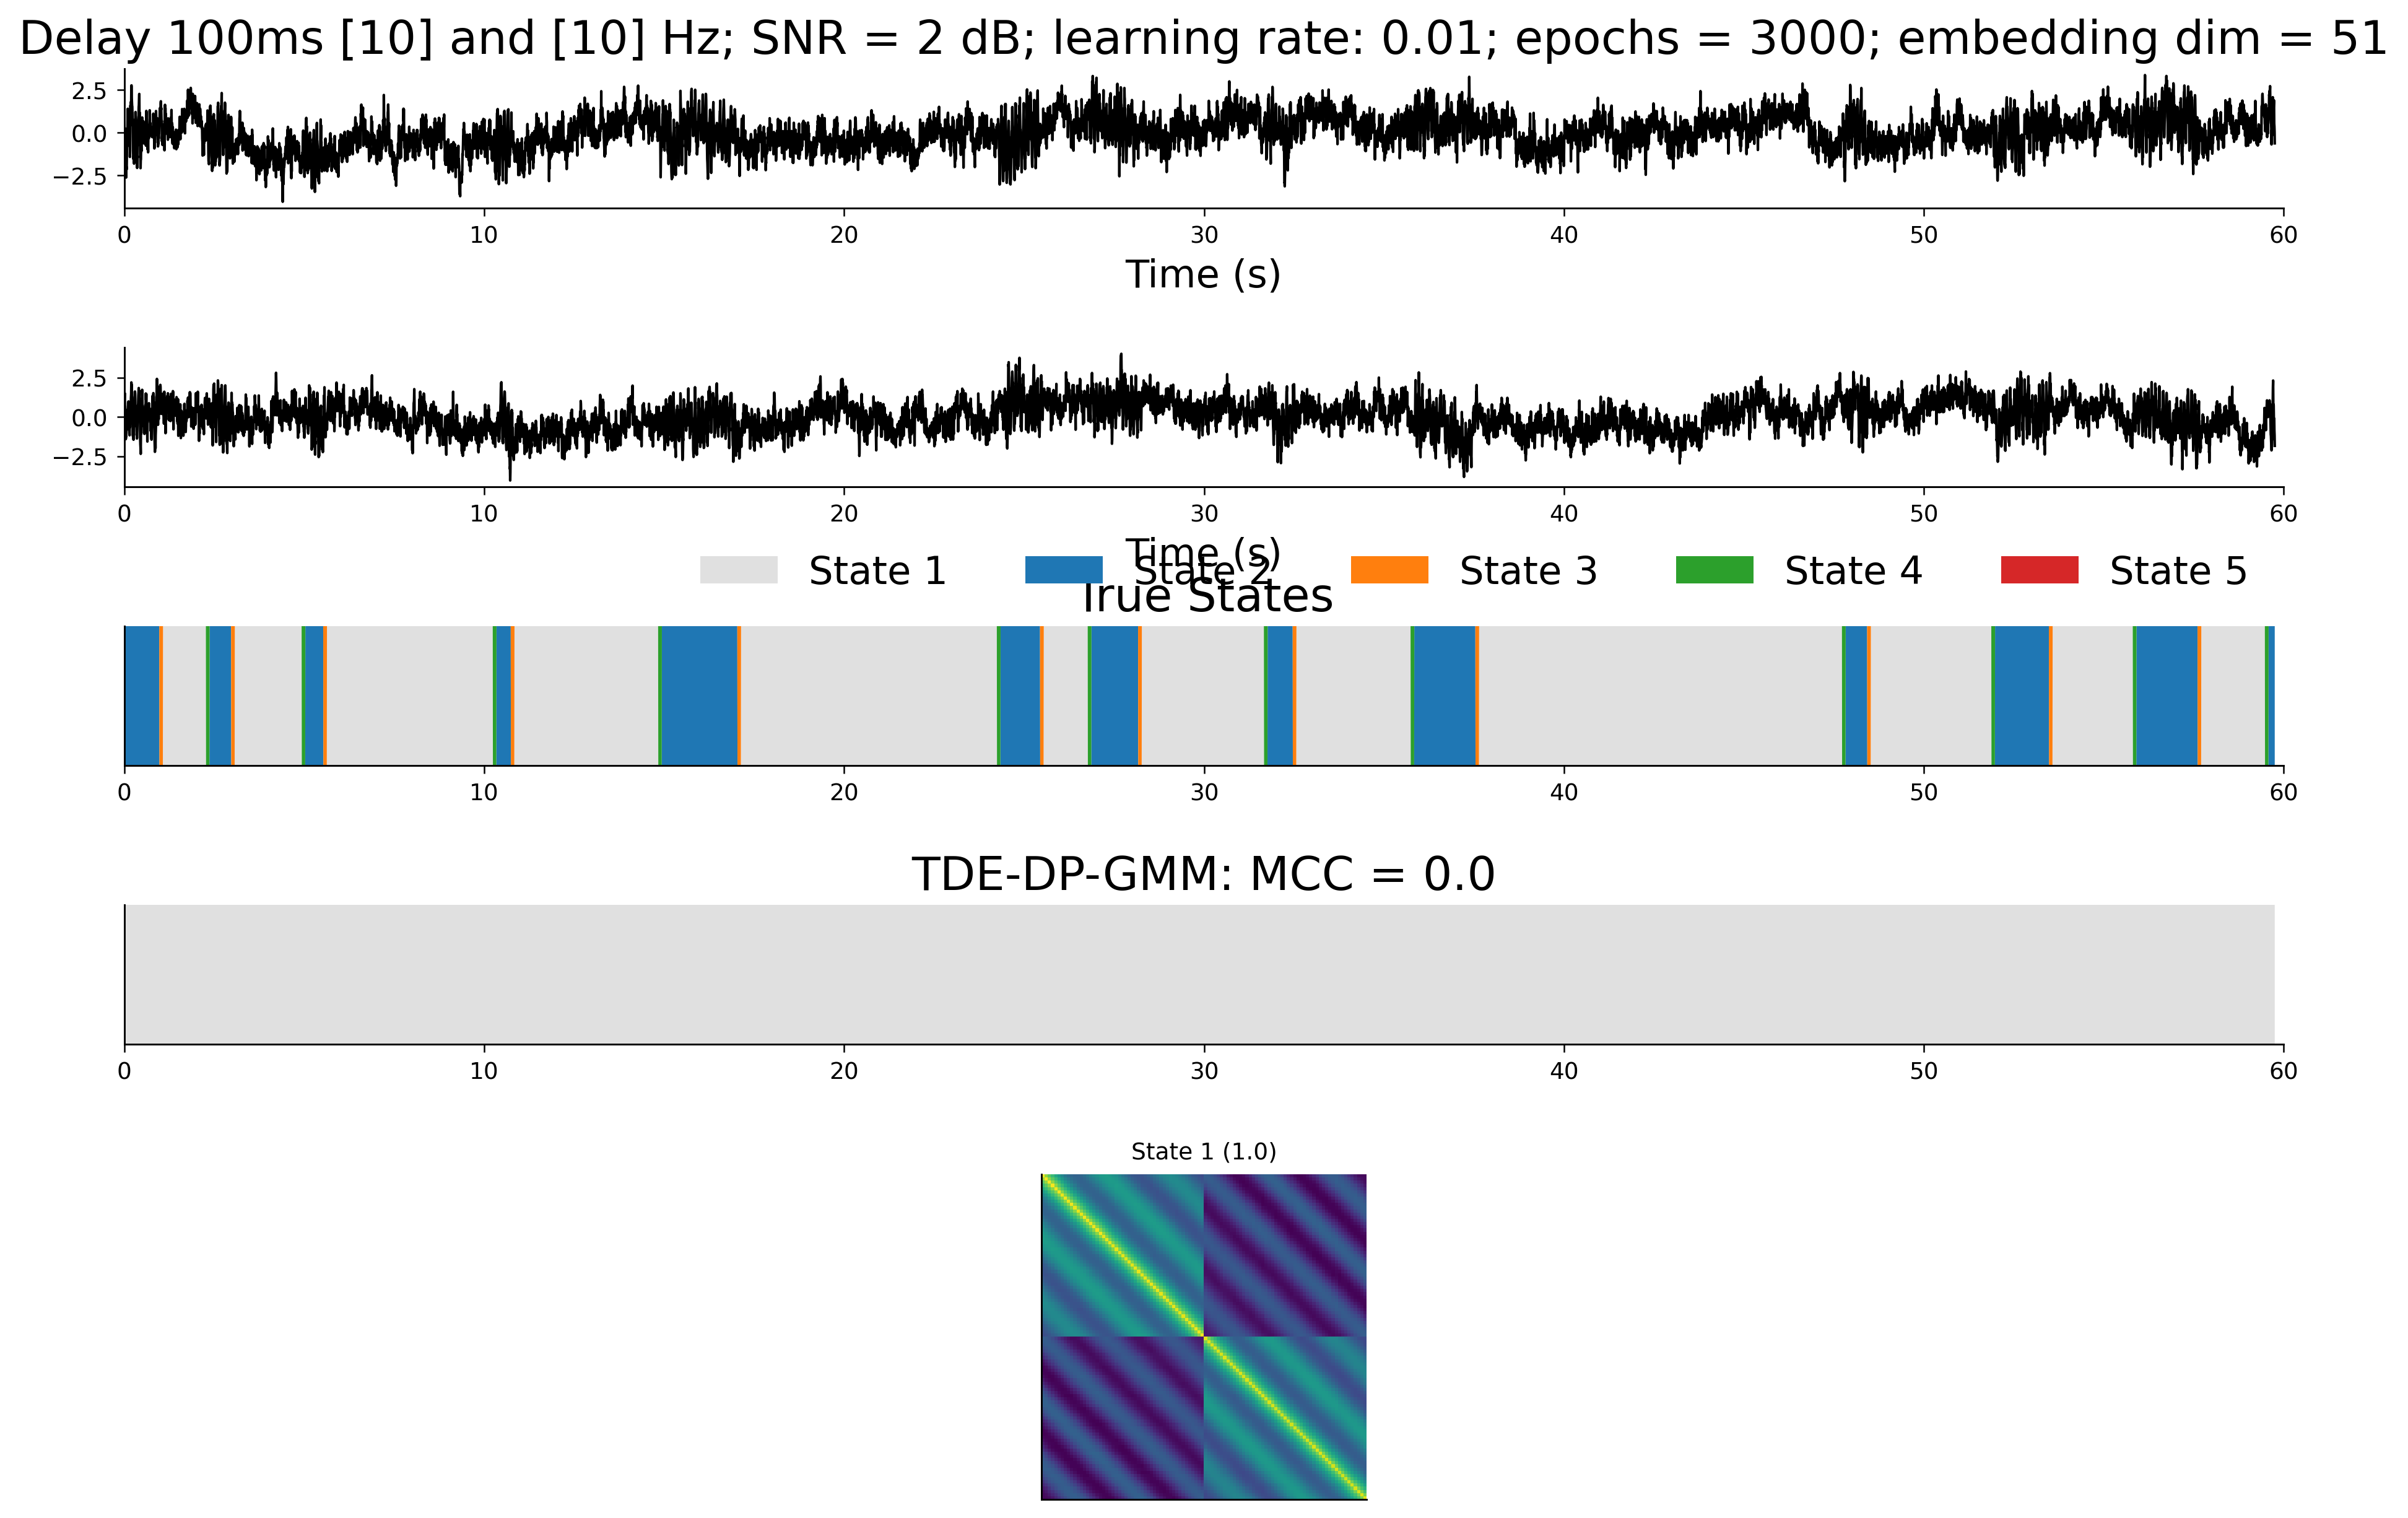

In [187]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]

# top row height larger than bottom row
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.2)

# top: 3 stacked subplots (share x)
ax_top = fig.add_subplot(gs[0])
ax_top.set_xticklabels([])
ax_top.set_yticklabels([])
ax_top.set_yticks([])
ax_top.set_xticks([])
ax_top.axis('off')
# create a small inner GridSpec to host 3 rows sharing x inside the top region
gs_top = gridspec.GridSpecFromSubplotSpec(nrows=4, ncols=1, subplot_spec=gs[0], hspace=1)

ax0 = fig.add_subplot(gs_top[0])
ax3 = fig.add_subplot(gs_top[1], sharex=ax0)
ax1 = fig.add_subplot(gs_top[2], sharex=ax0)
ax2 = fig.add_subplot(gs_top[3], sharex=ax0)

# first subplot (signal)
ax0.plot(trimmed_time_vec, trimmed_signal, color="k")
ax0.set_xlabel("Time (s)", fontsize=15)
ax0.set_title(heading + f"; learning rate: {lr}; epochs = {num_epochs}; embedding dim = {num_emb}", fontsize=18)
ax0.set_xlim(0, 60)


ax3.plot(trimmed_time_vec, trimmed_signal2, color="k")
ax3.set_xlabel("Time (s)", fontsize=15)
ax3.set_xlim(0, 60)





# second subplot (true states)
ax1.stackplot(trimmed_time_vec, trimmed_states_onehot.T, colors=colors, labels=state_labels, linewidth=0)
ax1.set_title("True States", fontsize=18)
ax1.set_ylim(0, 1)
ax1.set_yticks([])

# third subplot (estimated states)
ax2.stackplot(trimmed_time_vec, est_states_dpgmm_onehot.T, colors=colors, linewidth=0)
ax2.set_title(f"TDE-DP-GMM: MCC = {np.round(mcc_dpgmm, 3)}", fontsize=18)
ax2.set_ylim(0, 1)
ax2.set_yticks([])


ax1.legend(
    loc="lower right",
    bbox_to_anchor=(1.0, 1.0),
    ncol=num_states,
    frameon=False,
    fontsize=15,
)

# bottom row: covariance images
# determine number of cov axes horizontally
n_cov = trunc_covs.shape[0]
# create sub-gridspec for the bottom row with n_cov columns
gs_bottom = gridspec.GridSpecFromSubplotSpec(nrows=1, ncols=n_cov, subplot_spec=gs[1], wspace=0.1)

if n_cov == 1:
    ax_cov = fig.add_subplot(gs_bottom[0])
    ax_cov.imshow(trunc_covs[0], cmap="viridis")
    ax_cov.set_title("State 1 (" + str(trunc_weights[0]) + ")")
    ax_cov.set_xticks([])
    ax_cov.set_yticks([])
else:
    for i in range(n_cov):
        ax_cov = fig.add_subplot(gs_bottom[i])
        ax_cov.imshow(trunc_covs[i], cmap="viridis")
        ax_cov.set_title(f"State {i+1} ({trunc_weights[i] * 100:.1f}%)")
        ax_cov.set_xticks([])
        ax_cov.set_yticks([])

print(trunc_covs.shape)
plt.show()
